In [16]:
import pandas as pd
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix, plot_period_transactions
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. Set up connection (update credentials and host!)
from dotenv import dotenv_values

config = dotenv_values() 

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

engine = create_engine(url, echo=False)

# 2. Load data

my_schema = "team_3"

mart_all_data = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_all_data;",
    engine,
    parse_dates=['transaction_date']
)

holidays = pd.read_sql(
    f"SELECT * FROM {my_schema}.mart_holidays_2019_us;",
    engine,
    parse_dates=["date"]
)

In [22]:
#Prepare holidays dataframe - filter only national holidays
national_holidays = holidays[holidays['national_holiday'] == True].copy()
national_holidays.rename(columns={'date': 'transaction_date'}, inplace=True)
national_holidays['transaction_date'] = pd.to_datetime(national_holidays['transaction_date'])

# Prepare mart_all_data
mart_all_data['transaction_date'] = pd.to_datetime(mart_all_data['transaction_date'])


In [23]:
print(mart_all_data.columns)

Index(['transaction_date', 'transaction_id', 'customer_id', 'customer_gender',
       'customer_location', 'customer_tenure_months', 'produkt_sku',
       'product_category', 'quantity', 'avg_price', 'delivery_charges',
       'revenue', 'coupon_status', 'discount_pct', 'gst_onsale',
       'daily_offline', 'daily_online', 'transaction_month',
       'transaction_month_str'],
      dtype='object')


In [24]:
#Create holiday flag column
mart_all_data = mart_all_data.merge(
    national_holidays[['transaction_date', 'name']],
    on='transaction_date',
    how='left'
)


In [25]:
mart_all_data['is_national_holiday'] = mart_all_data['name'].notna()

# Optional: fill NaNs with 'No Holiday'
mart_all_data['name'].fillna('No Holiday', inplace=True)


In [26]:
national_holidays.head()

,name,description,transaction_date,type,religious_holiday,local_holiday,national_holiday,worldwide_observance
0,New Year's Day,New Year's Day is the first day of the Gregori...,2019-01-01,National holiday,False,False,True,False
12,Martin Luther King Jr. Day,Martin Luther King Day marks the anniversary o...,2019-01-21,National holiday,False,False,True,False
308,Labor Day,Labor Day is a federal holiday in the United S...,2019-09-02,National holiday,False,False,True,False
404,Veterans Day,Veterans Day in the USA is a holiday to honor ...,2019-11-11,National holiday,False,False,True,False
418,Thanksgiving Day,Thanksgiving Day in the United States is tradi...,2019-11-28,National holiday,False,False,True,False


In [29]:
#Calculate TotalAmount (monetary value)
mart_all_data['TotalAmount'] = mart_all_data['quantity'] * mart_all_data['avg_price']

# Step 7: Drop rows with missing customer_id (essential for CLV)
mart_all_data.dropna(subset=['customer_id'], inplace=True)

# Step 8: Generate summary data (RFM) for CLV modeling
summary = summary_data_from_transaction_data(
    mart_all_data,
    customer_id_col='customer_id',
    datetime_col='transaction_date',
    monetary_value_col='TotalAmount',
    observation_period_end=mart_all_data['transaction_date'].max()
).reset_index()

# Filter out invalid customers with non-positive monetary or zero frequency
summary = summary[(summary['monetary_value'] > 0) & (summary['frequency'] > 0)]

print("RFM Summary sample:")
print(summary.head())

# Step 9: Fit BG/NBD model (purchase frequency and repeat buying behavior)
bgf = BetaGeoFitter(penalizer_coef=0.0)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

# Fit Gamma-Gamma model (monetary value per transaction)
ggf = GammaGammaFitter(penalizer_coef=0.0)
ggf.fit(summary['frequency'], summary['monetary_value'])

# Step 10: Predict customer lifetime value (CLV) for next 30 days
summary['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    summary['frequency'],
    summary['recency'],
    summary['T'],
    summary['monetary_value'],
    time=30,
    freq='D',
    discount_rate=0.01
)

print("Top 5 customers by predicted CLV:")
print(summary[['customer_id', 'predicted_clv']].sort_values(by='predicted_clv', ascending=False).head())


RFM Summary sample:
   customer_id  frequency  recency      T  monetary_value
1        12347        2.0    223.0  282.0     1309.425000
2        12348        1.0    119.0  192.0      665.090000
6        12370        1.0     30.0  219.0      635.300000
8        12377        1.0    139.0  179.0     6545.830000
9        12383        3.0     72.0  171.0      745.476667
Top 5 customers by predicted CLV:
      customer_id  predicted_clv
736         15311   61155.814000
563         14606   49080.563502
643         14911   43754.438039
1355        17841   40927.728511
202         13089   28443.590801


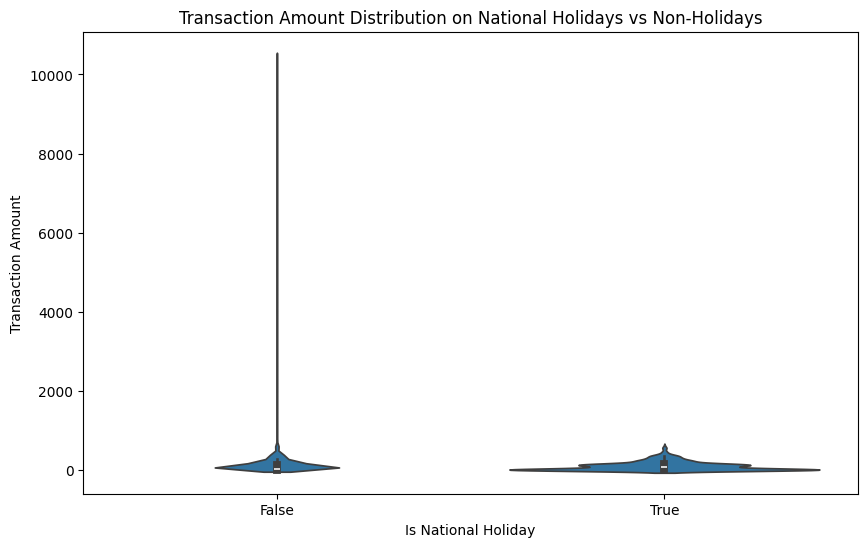

In [32]:
#Step 11: Analyze effect of national holidays on transaction amounts
plt.figure(figsize=(10,6))
sns.violinplot(x='is_national_holiday', y='TotalAmount', data=mart_all_data)
plt.title('Transaction Amount Distribution on National Holidays vs Non-Holidays')
plt.xlabel('Is National Holiday')
plt.ylabel('Transaction Amount')
plt.show()

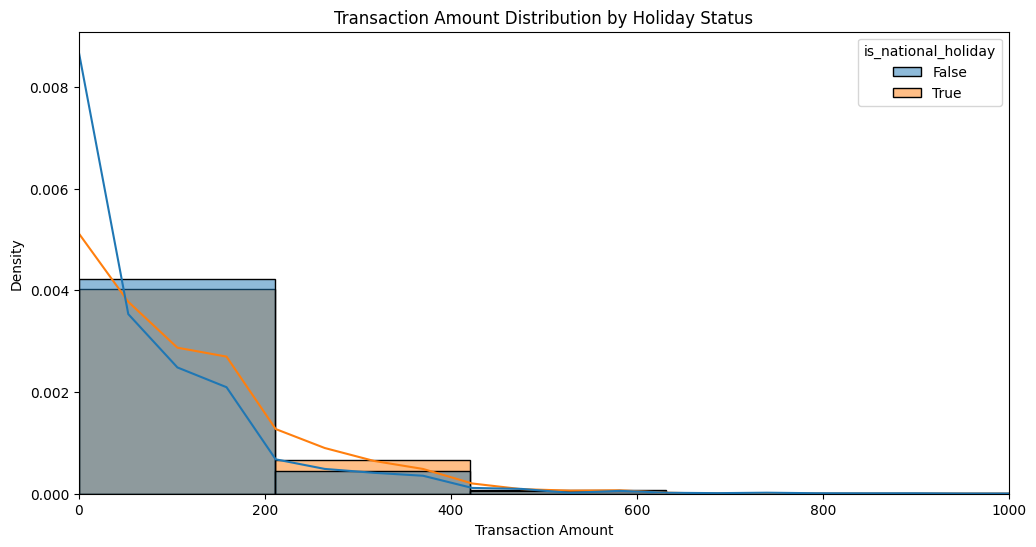

In [33]:
plt.figure(figsize=(12,6))
sns.histplot(data=mart_all_data, x='TotalAmount', hue='is_national_holiday', bins=50, kde=True, stat="density", common_norm=False)
plt.title('Transaction Amount Distribution by Holiday Status')
plt.xlabel('Transaction Amount')
plt.ylabel('Density')
plt.xlim(0, 1000)  # Optional zoom to focus on most transactions
plt.show()

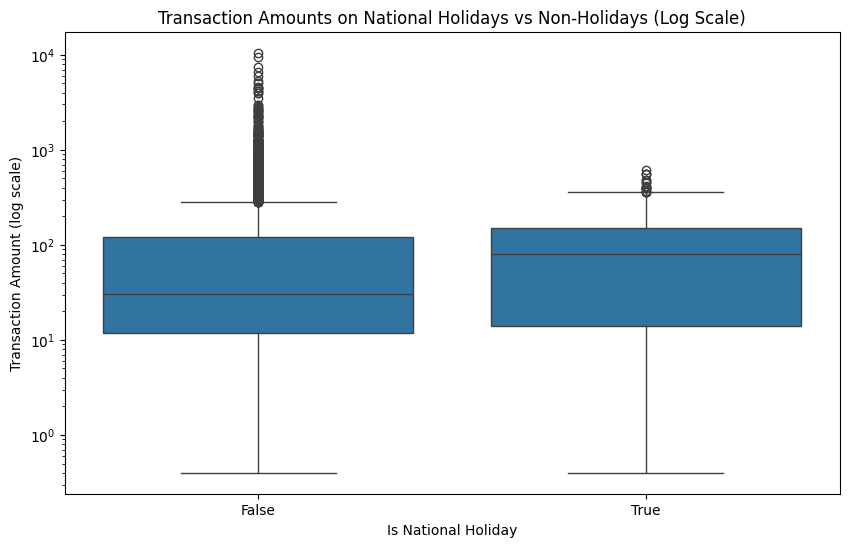

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(x='is_national_holiday', y='TotalAmount', data=mart_all_data)
plt.yscale('log')
plt.title('Transaction Amounts on National Holidays vs Non-Holidays (Log Scale)')
plt.xlabel('Is National Holiday')
plt.ylabel('Transaction Amount (log scale)')
plt.show()

   is_national_holiday        mean  median  count
0                False   88.064411   30.39  52353
1                 True  105.706673   79.99    571


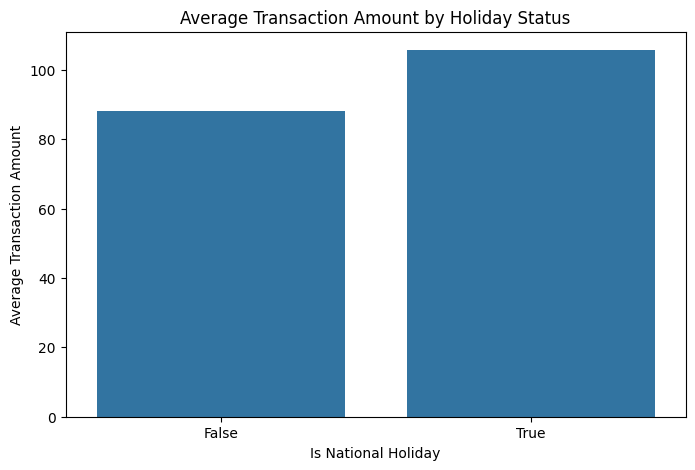

In [35]:
summary_stats = mart_all_data.groupby('is_national_holiday')['TotalAmount'].agg(['mean', 'median', 'count']).reset_index()
print(summary_stats)

plt.figure(figsize=(8,5))
sns.barplot(x='is_national_holiday', y='mean', data=summary_stats)
plt.title('Average Transaction Amount by Holiday Status')
plt.xlabel('Is National Holiday')
plt.ylabel('Average Transaction Amount')
plt.show()

In [36]:
# Aggregate total revenue by holiday flag
revenue_summary = mart_all_data.groupby('is_national_holiday')['TotalAmount'].agg(['sum', 'mean', 'count']).reset_index()
revenue_summary['is_national_holiday'] = revenue_summary['is_national_holiday'].map({True: 'Holiday', False: 'Non-Holiday'})

print(revenue_summary)

  is_national_holiday         sum        mean  count
0         Non-Holiday  4610436.11   88.064411  52353
1             Holiday    60358.51  105.706673    571


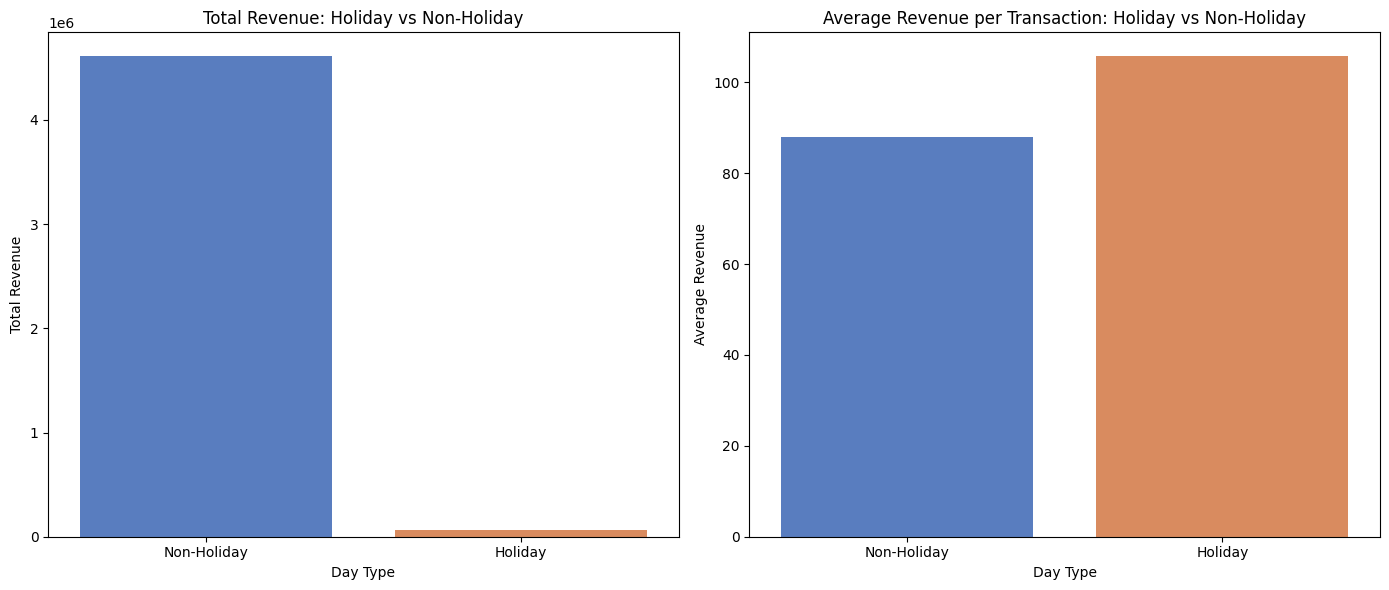

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

# Total Revenue Bar Plot
plt.subplot(1,2,1)
sns.barplot(x='is_national_holiday', y='sum', data=revenue_summary, palette='muted')
plt.title('Total Revenue: Holiday vs Non-Holiday')
plt.ylabel('Total Revenue')
plt.xlabel('Day Type')

# Average Revenue per Transaction Bar Plot
plt.subplot(1,2,2)
sns.barplot(x='is_national_holiday', y='mean', data=revenue_summary, palette='muted')
plt.title('Average Revenue per Transaction: Holiday vs Non-Holiday')
plt.ylabel('Average Revenue')
plt.xlabel('Day Type')

plt.tight_layout()
plt.show()


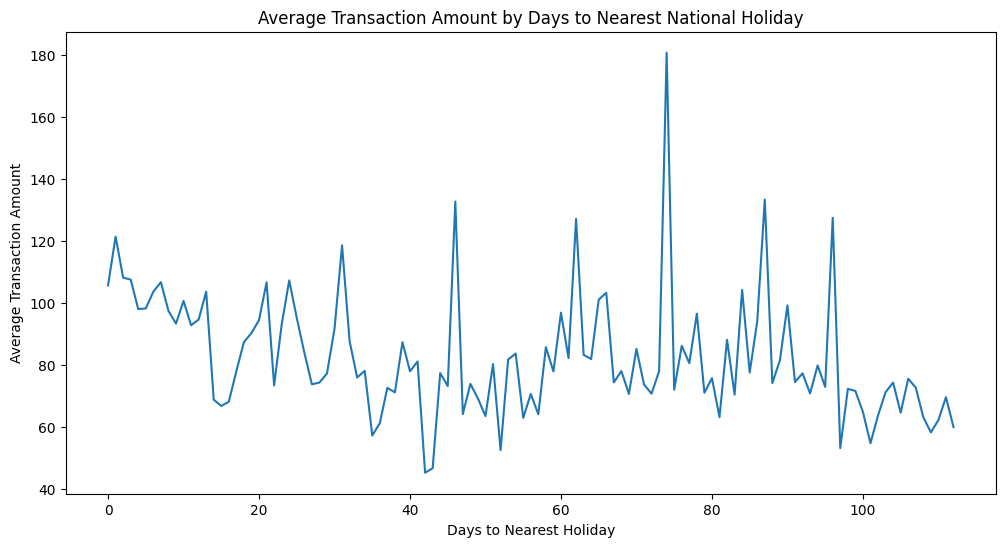

In [38]:
# Convert dates to datetime if not already
mart_all_data['transaction_date'] = pd.to_datetime(mart_all_data['transaction_date'])
national_holidays['transaction_date'] = pd.to_datetime(national_holidays['transaction_date'])

# Create a set of holiday dates for quick lookup
holiday_dates = set(national_holidays['transaction_date'])

# Calculate days to nearest holiday for each transaction
def days_to_nearest_holiday(date):
    return min(abs((date - hd).days) for hd in holiday_dates)

mart_all_data['days_to_holiday'] = mart_all_data['transaction_date'].apply(days_to_nearest_holiday)

# Aggregate average revenue by days_to_holiday
revenue_by_days = mart_all_data.groupby('days_to_holiday')['TotalAmount'].mean().reset_index()

# Plot
plt.figure(figsize=(12,6))
sns.lineplot(x='days_to_holiday', y='TotalAmount', data=revenue_by_days)
plt.title('Average Transaction Amount by Days to Nearest National Holiday')
plt.xlabel('Days to Nearest Holiday')
plt.ylabel('Average Transaction Amount')
plt.show()